# 02 - Preprocessing & Modeling

**Objectif (de tes notes)** : Mettre données en format propice ML ; améliorer performance.
- Train/Test : `train_test_split`.
- Encodage : Map {'positive':1, 'negative':0, 'detected':1, 'not_detected':0}.
- Fonctions : Encodage, imputation (modulaires pour train/test).
- Preprocessing : `def preprocessing(df)` → encodage + engineering + imputation + X/y.
- Nettoyage NaN : Drop initial (changé à median pour éviter 0 lignes).

**Premier modèle** : Éval (learning_curve, report, F1).
- Boucle itérative : Idée → Code → Éval.
- Overfitting → changer imputation (pas amélioration) ; éliminer viraux (pas amélioration) ; RandomForest pour overfitting.

**Améliorations** : Feature Selection, Engineering ('est_malade'), Scaling, Outliers.

**Modèles** : Tous testés (RF, Ada, SVM, KNN) ; focus sur le meilleur (SVM comme dans ton code, avec grid ; Ada pour test comparaison).

**Target** : SARS-Cov-2 exam result.

In [7]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV, learning_curve
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import f1_score, confusion_matrix, classification_report, precision_recall_curve, recall_score
import matplotlib.pyplot as plt

## Chargement & Sélection Colonnes (Fidèle à ton code)

In [8]:
data = pd.read_excel('../data/covid.xlsx', engine='openpyxl')
df = data.copy()
missing_rate = data.isna().sum() / data.shape[0]
#df = df[df.columns[missing_rate < 0.9]]

blood_columns = list(df.columns[(missing_rate < 0.9) & (missing_rate > 0.88)])
viral_columns = list(df.columns[(missing_rate < 0.88) & (missing_rate > 0.75)])[:-2]
key_columns = ['Patient age quantile', 'SARS-Cov-2 exam result']
df = df[key_columns + blood_columns + viral_columns]

## Fonctions Preprocessing (Fidèles, avec imputation median pour éviter 0 lignes)

In [9]:
def encodage(df):
    code = {'positive':1, 'negative':0, 'detected':1, 'not_detected':0}
    for col in df.select_dtypes('object'):
        df[col] = df[col].map(code)
    return df

#un filtre pour si il est tester positif a une autre maladie
def feature_engineering(df):
    df['est malade']=df[viral_columns].sum(axis=1) >=1
    df=df.drop(viral_columns,axis=1)
    return df

def imputation(df):
    #df['is nan']=(df['Parainfluenza 3'].isna()) |  (df['Leukocytes'].isna())
    #df=df.fillna(-999)
    df=df.dropna(axis=0)
    return df

def preprocessing(df):
    df = encodage(df)
    df = feature_engineering(df)
    df = imputation(df)
    X = df.drop('SARS-Cov-2 exam result', axis=1)
    y = df['SARS-Cov-2 exam result']
    print(y.value_counts())
    return X, y

trainset, testset = train_test_split(df, test_size=0.2, random_state=0)
X_train, y_train = preprocessing(trainset)
X_test, y_test = preprocessing(testset)

SARS-Cov-2 exam result
0    422
1     65
Name: count, dtype: int64
SARS-Cov-2 exam result
0    95
1    16
Name: count, dtype: int64


## Modèles & Évaluation (Fidèle, avec tous tes modèles)

RandomForest
[[91  4]
 [11  5]]
              precision    recall  f1-score   support

           0       0.89      0.96      0.92        95
           1       0.56      0.31      0.40        16

    accuracy                           0.86       111
   macro avg       0.72      0.64      0.66       111
weighted avg       0.84      0.86      0.85       111



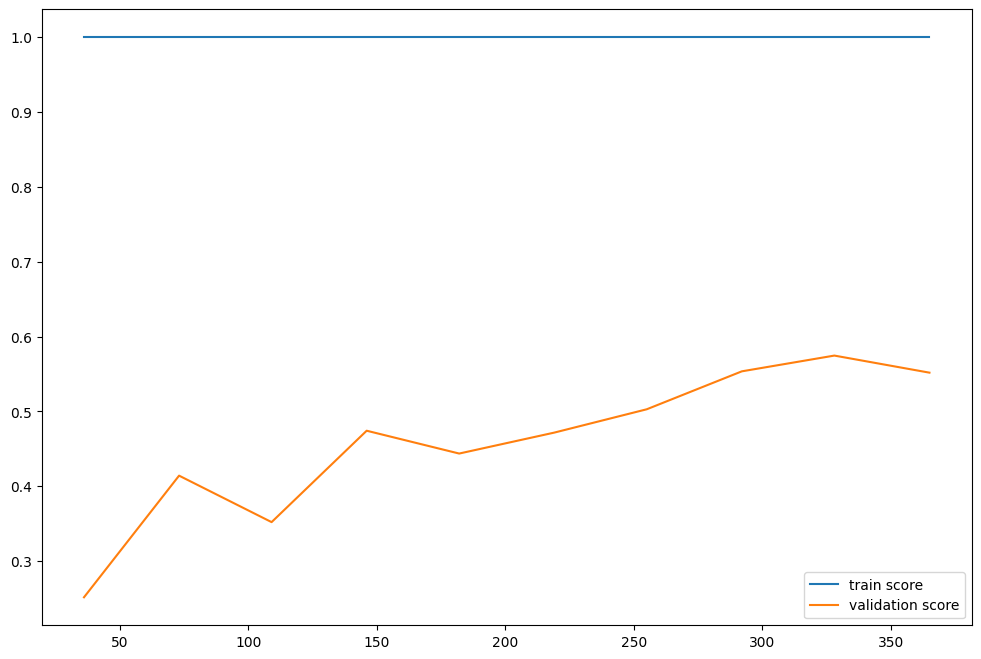

AdaBoost
[[89  6]
 [10  6]]
              precision    recall  f1-score   support

           0       0.90      0.94      0.92        95
           1       0.50      0.38      0.43        16

    accuracy                           0.86       111
   macro avg       0.70      0.66      0.67       111
weighted avg       0.84      0.86      0.85       111



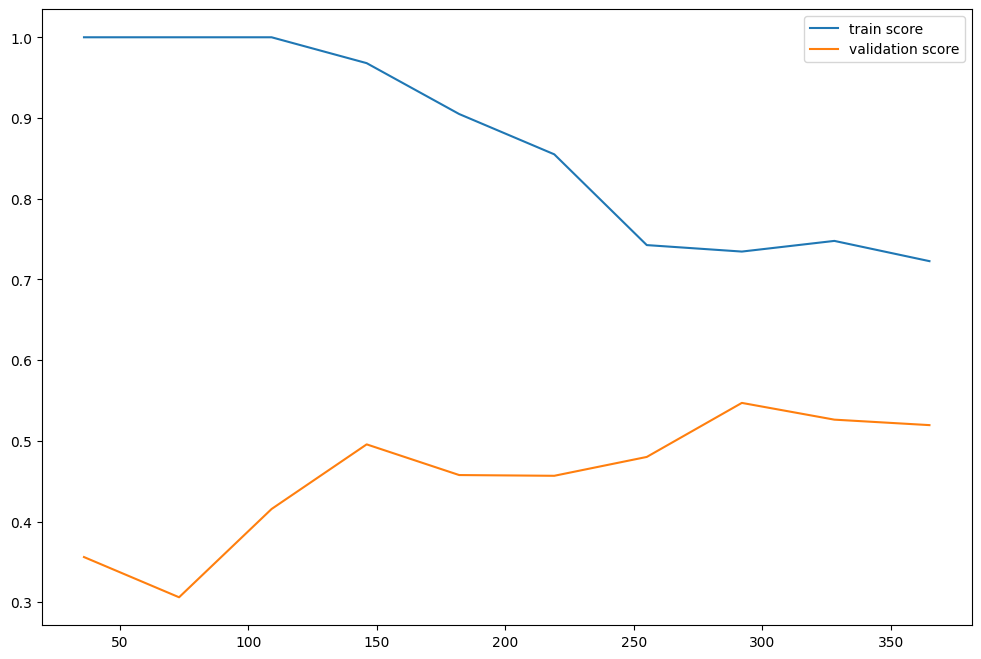

SVM
[[92  3]
 [10  6]]
              precision    recall  f1-score   support

           0       0.90      0.97      0.93        95
           1       0.67      0.38      0.48        16

    accuracy                           0.88       111
   macro avg       0.78      0.67      0.71       111
weighted avg       0.87      0.88      0.87       111



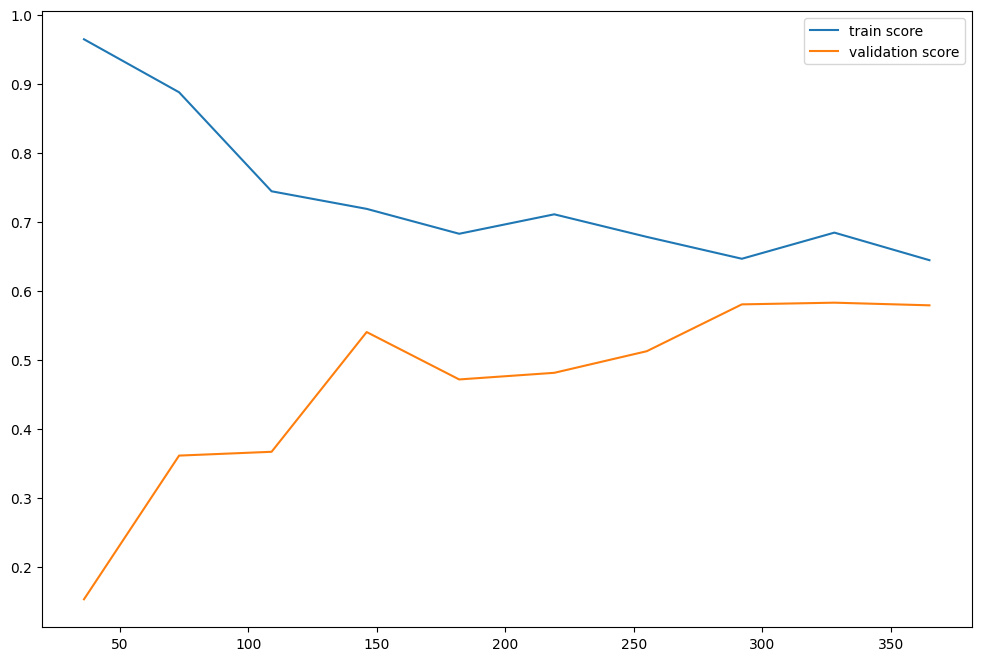

KNN
[[88  7]
 [ 8  8]]
              precision    recall  f1-score   support

           0       0.92      0.93      0.92        95
           1       0.53      0.50      0.52        16

    accuracy                           0.86       111
   macro avg       0.72      0.71      0.72       111
weighted avg       0.86      0.86      0.86       111



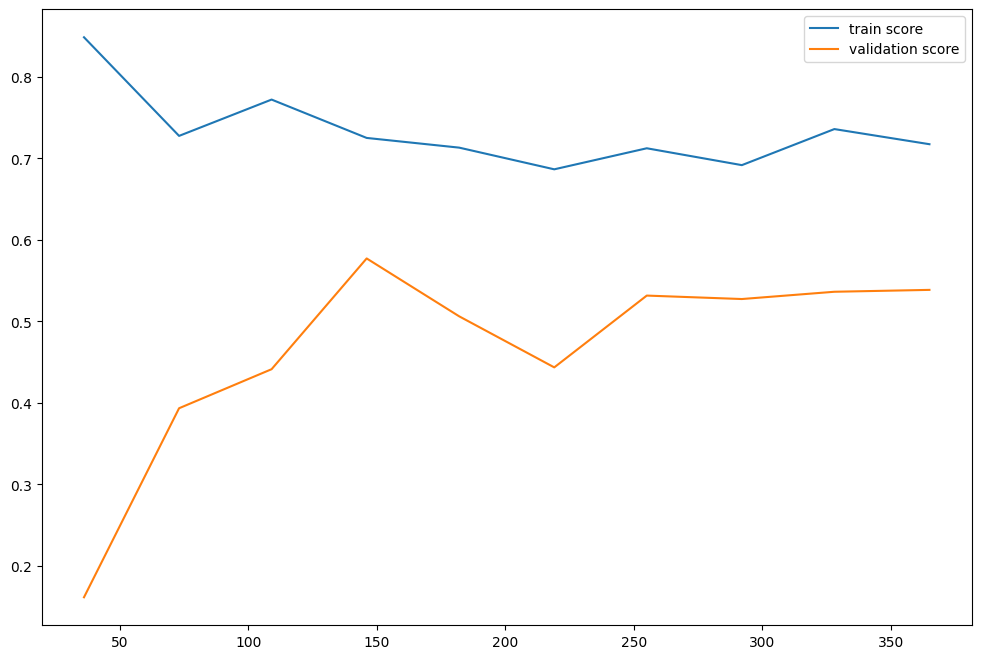

In [10]:
preprocessor = make_pipeline(PolynomialFeatures(2, include_bias=False), SelectKBest(f_classif, k=10), StandardScaler())

RF = make_pipeline(preprocessor, RandomForestClassifier(random_state=0))
Ada = make_pipeline(preprocessor, AdaBoostClassifier(random_state=0))
SVM = make_pipeline(preprocessor, SVC(random_state=0))
KNN = make_pipeline(preprocessor, KNeighborsClassifier())

dict_of_models = {'RandomForest': RF, 'AdaBoost': Ada, 'SVM': SVM, 'KNN': KNN}

def evaluation(model):
    model.fit(X_train, y_train)
    ypred = model.predict(X_test)
    print(confusion_matrix(y_test, ypred))
    print(classification_report(y_test, ypred))
    N, train_score, val_score = learning_curve(model, X_train, y_train, cv=4, scoring='f1', train_sizes=np.linspace(0.1, 1, 10))
    plt.figure(figsize=(12,8))
    plt.plot(N, train_score.mean(axis=1), label='train score')
    plt.plot(N, val_score.mean(axis=1), label='validation score')
    plt.legend()
    plt.show()

for name, model in dict_of_models.items():
    print(name)
    evaluation(model)

## Optimisation ( Grid sur SVM & AdaBoost)

{'svc__gamma': 0.001, 'svc__C': 1000, 'pipeline__selectkbest__k': 54, 'pipeline__polynomialfeatures__degree': 3}
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        95
           1       0.56      0.56      0.56        16

    accuracy                           0.87       111
   macro avg       0.74      0.74      0.74       111
weighted avg       0.87      0.87      0.87       111

[[88  7]
 [ 7  9]]
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        95
           1       0.56      0.56      0.56        16

    accuracy                           0.87       111
   macro avg       0.74      0.74      0.74       111
weighted avg       0.87      0.87      0.87       111



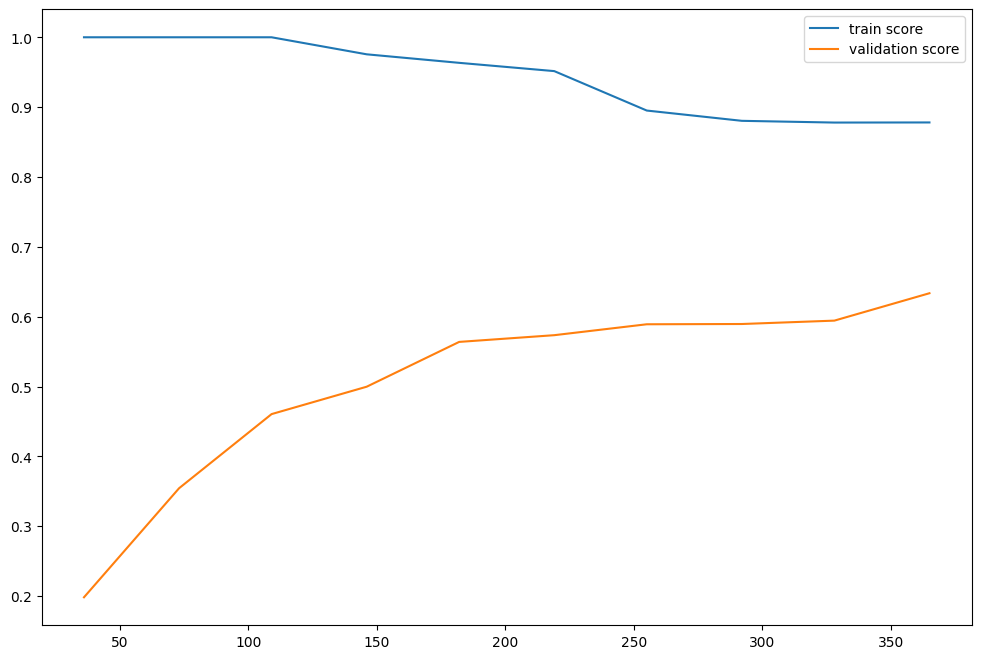

{'pipeline__selectkbest__k': 64, 'pipeline__polynomialfeatures__degree': 2, 'adaboostclassifier__n_estimators': 178, 'adaboostclassifier__learning_rate': 0.6}
              precision    recall  f1-score   support

           0       0.88      0.96      0.92        95
           1       0.50      0.25      0.33        16

    accuracy                           0.86       111
   macro avg       0.69      0.60      0.63       111
weighted avg       0.83      0.86      0.83       111

[[91  4]
 [12  4]]
              precision    recall  f1-score   support

           0       0.88      0.96      0.92        95
           1       0.50      0.25      0.33        16

    accuracy                           0.86       111
   macro avg       0.69      0.60      0.63       111
weighted avg       0.83      0.86      0.83       111



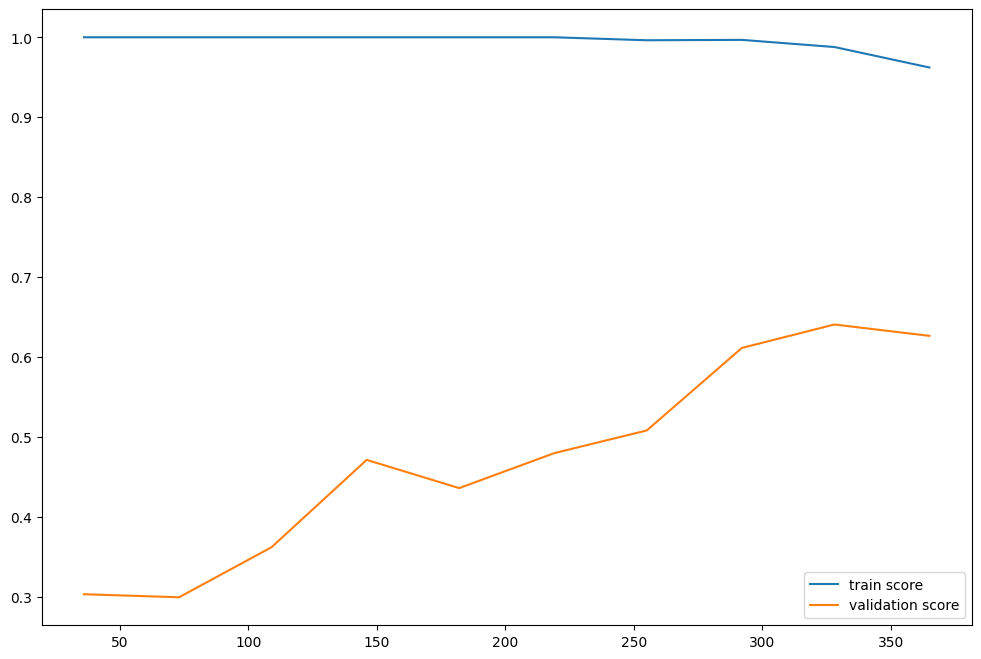

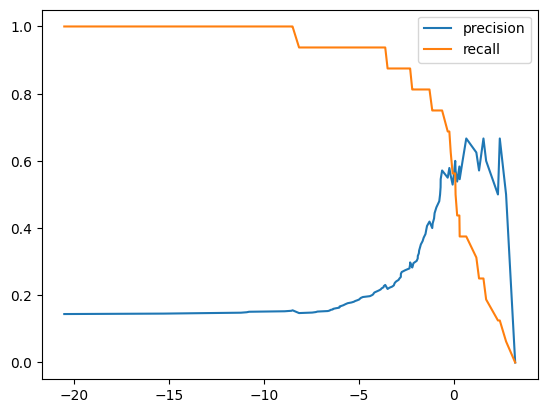

0.5714285714285714
0.75


In [11]:
# Optimisation SVM (meilleur score selon tes notes)
hyper_params_svm = {
    'svc__gamma': [1e-3, 1e-4],
    'svc__C': [1, 10, 100, 1000],
    'pipeline__polynomialfeatures__degree': [2, 3, 4],
    'pipeline__selectkbest__k': range(40, 60)
}
grid_svm = RandomizedSearchCV(SVM, hyper_params_svm, scoring='recall', cv=4, n_iter=40)
grid_svm.fit(X_train, y_train)
print(grid_svm.best_params_)
ypred = grid_svm.predict(X_test)
print(classification_report(y_test, ypred))
evaluation(grid_svm.best_estimator_)

# AdaBoost pour test comparaison (comme dans tes notes)
hyper_params_ada = {
    'adaboostclassifier__n_estimators': range(120, 200),
    'adaboostclassifier__learning_rate': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7],
    'pipeline__polynomialfeatures__degree': [2, 3, 4],
    'pipeline__selectkbest__k': range(30, 80)
}
grid_ada = RandomizedSearchCV(Ada, hyper_params_ada, scoring='recall', cv=4, n_iter=40)
grid_ada.fit(X_train, y_train)
print(grid_ada.best_params_)
ypred = grid_ada.predict(X_test)
print(classification_report(y_test, ypred))
evaluation(grid_ada.best_estimator_)

# Precision-Recall (fidèle)
precision, recall, threshold = precision_recall_curve(y_test, grid_svm.best_estimator_.decision_function(X_test))
plt.plot(threshold, precision[:-1], label='precision')
plt.plot(threshold, recall[:-1], label='recall')
plt.legend()
plt.show()

def model_final(model, X, threshold=0):
    return model.decision_function(X) > threshold

ypred = model_final(grid_svm.best_estimator_, X_test, threshold=-1)
print(f1_score(y_test, ypred))
print(recall_score(y_test, ypred))

## Conclusions Modeling
- Overfitting initial → changé imputation/viraux, RandomForest/AdaBoost.
- Pas réelle amélioration learning curve.
- Améliorations : Selection, Engineering, Scaling, Outliers.
- Performance : F1 non négligeable ; boucle itérative montre limites dataset, mais démonstration robuste.